# Task 3: CycleGAN photo ↔ Monet

Two ResNet generators (G_AB: photo→Monet, G_BA: Monet→photo, resize-conv upsampling) and two PatchGAN discriminators, trained with LSGAN adversarial + cycle-consistency + identity loss. The Kaggle submission comes only from my own generators: v3's `G_AB.pt` (the earlier version this run continues from; see section 4) applied to all 7,038 photos.

**Final run** (`config.yaml`, `src/run_final.py`, NVIDIA RTX 4090, bf16): v2's weights were trained further with v3's recipe (translation-only DiffAugment on the discriminator inputs, EMA copies of both generators) on a long schedule: 270 epochs × 1,000 steps, constant learning rate for 40% of the run, then linear decay to zero. Every few epochs the run scored both generators on held-out photos, trying raw and EMA weights for each direction, and kept the best pair; the winner is promoted to `checkpoints/`. A second variant was started alongside it and stopped early (see section 2).

| Variant | What it tested | Outcome |
|---|---|---|
| V2_CONTINUE | v2's weights + v3's recipe, run long | finished all 270 epochs (6.9 h); promoted |
| MSD_TEXTURE | v2's generators + fresh two-scale discriminators + cycle weight decayed 10 → 3 | stopped at step 6,800 (its 7th epoch) when the run was restarted with V2_CONTINUE alone |

`outputs/pred_A2B` (all 300 Monet → photo) and `outputs/pred_B2A` (all 7,038 photos → Monet) are scored with the instructor's `Part3_Evaluation_Script.ipynb` (section 4). Earlier runs (v1–v3) are summarised at the end of this notebook.

In [1]:
# Works on a local kernel (this Mac: CUDA > Apple MPS > CPU) and on a Colab GPU runtime.
MEMBER = "sivasurya_chandran"
TASK = "task3_gan"
DRIVE_REPO = "/content/drive/MyDrive/DATA266/lab1/repo"   # used only on Colab (found automatically below)

import os, sys, json, glob
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.isdir("/content/drive/MyDrive"):
        from google.colab import drive
        drive.mount("/content/drive")
    # The DATA266 folder may be in this account's My Drive, or shared from another account ("Shared with me").
    # Colab does not mount "Shared with me" itself; a shared folder is reachable once it has a shortcut in
    # My Drive (Drive web: Shared with me > right-click DATA266 > Organize > Add shortcut > My Drive).
    candidates = [DRIVE_REPO] + sorted(glob.glob("/content/drive/MyDrive/**/DATA266/lab1/repo", recursive=True)) \
        + sorted(glob.glob("/content/drive/.shortcut-targets-by-id/*/DATA266/lab1/repo")) \
        + sorted(glob.glob("/content/drive/.shortcut-targets-by-id/*/lab1/repo")) \
        + sorted(glob.glob("/content/drive/Shareddrives/*/DATA266/lab1/repo"))
    found = [c for c in candidates if os.path.isdir(os.path.join(c, "tools"))]
    if not found:
        raise SystemExit("DATA266/lab1/repo not found on the mounted Drive. If it is shared with you, add a shortcut: "
                         "drive.google.com > Shared with me > right-click DATA266 > Organize > Add shortcut > My Drive, then re-run this cell.")
    DRIVE_REPO = found[0]
    print("Drive repo:", DRIVE_REPO)
    sys.path.insert(0, f"{DRIVE_REPO}/tools")
    import colab
    colab.setup(DRIVE_REPO, TASK, MEMBER)
else:
    if os.path.basename(os.getcwd()) == "src":   # VS Code starts the kernel next to the notebook
        os.chdir("..")
    sys.path.insert(0, os.path.abspath("../../tools"))
    import colab   # only launch()/monitor() are used locally
    import torch
    dev = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    print("working in", os.path.relpath(os.getcwd(), os.path.abspath("../..")), "| torch", torch.__version__, "| device:", dev)

working in task3_gan/sivasurya_chandran | torch 2.8.0 | device: mps


In [2]:
# Monet/photo images + real_stats.npz -> ../data (task3_gan/data). Kaggle token: KAGGLE_API_TOKEN or ~/.kaggle/access_token,
# else a hidden prompt (kaggle.com > Settings > API). The token is never written to the repo.
# Without the Kaggle API: python ../download_data.py --zip <the instructor's dataset.zip or the competition zip>
if len(glob.glob("../data/photo_jpg/*.jpg")) < 7038 or len(glob.glob("../data/monet_jpg/*.jpg")) < 300:
    has_token = any(os.path.exists(os.path.expanduser(f"~/.kaggle/{f}")) for f in ("access_token", "kaggle.json")) or "KAGGLE_API_TOKEN" in os.environ
    if not has_token:
        from getpass import getpass
        os.environ["KAGGLE_API_TOKEN"] = getpass("Kaggle API token (KGAT_...): ")
    !"{sys.executable}" -m pip install -q "kaggle>=1.8"
    !"{sys.executable}" ../download_data.py
print("photos:", len(glob.glob("../data/photo_jpg/*.jpg")), "| monet:", len(glob.glob("../data/monet_jpg/*.jpg")))

photos: 7038 | monet: 300


## 1. Final training run

`HOURS` is the whole budget (training + about 20 min of evaluation, translation and scoring). The run continues if this notebook is closed; re-running the cell after an interruption resumes every unfinished variant. Running `python src/run_final.py --hours 9.5` in a terminal does the same.

In [3]:
HOURS = 9.5
import subprocess
pid_file = "logs/run_final.pid"
def run_final_alive():
    try:
        os.kill(int(open(pid_file).read()), 0)
        return True
    except (OSError, ValueError):
        return False
if os.path.exists("checkpoints/variants_summary.json") and os.path.exists("checkpoints/G_AB.pt") and not run_final_alive():
    print("final run already finished: see the cells below")
elif os.path.exists(pid_file) and run_final_alive():
    print("already running; use the monitor cell")
else:
    os.makedirs("logs", exist_ok=True)
    subprocess.Popen([sys.executable, "src/run_final.py", "--hours", str(HOURS)],
                     stdout=open("logs/run_final_console.txt", "a"), stderr=subprocess.STDOUT)
    print(f"started src/run_final.py --hours {HOURS}; progress in logs/final_run_status.log")

final run already finished: see the cells below


In [4]:
# Live progress (status log + latest line of each variant). Interrupting this cell does NOT stop training.
import time
from IPython.display import clear_output
while True:
    clear_output(wait=True)
    status = open("logs/final_run_status.log").read().splitlines() if os.path.exists("logs/final_run_status.log") else []
    print("\n".join(status[-14:]))
    for f in sorted(glob.glob("logs/stdout_*.txt")):
        lines = [l for l in open(f, errors="replace").read().splitlines() if l.startswith("[")]
        fid = [l for l in lines if "select_score" in l]
        print("\n" + (lines[-1][:190] if lines else f))
        if fid:
            print("   " + fid[-1][:190])
    if any("ALL DONE" in l for l in status):
        break
    print(f"\n[{time.strftime('%H:%M:%S')}] refreshing every 60 s")
    time.sleep(60)

[2026-10-02 11:38:22] V2_CONTINUE: best held-out score 49.267, FID 98.13 (epoch 269, raw_raw), 270000 steps in 6.88 h
[2026-10-02 11:38:22] WINNER: V2_CONTINUE -> promoted to checkpoints/ and logs/train_raw.log
[2026-10-02 11:38:22] evaluate: C:\Program Files\Python39\python.exe src/evaluate.py --config config.yaml
[2026-10-02 11:39:07] evaluate ok (45s)
[2026-10-02 11:39:07] translate: C:\Program Files\Python39\python.exe src/translate.py --config config.yaml --input ../data/photo_jpg --output outputs\pred_B2A --flat
[2026-10-02 11:40:05] translate ok (57s)
[2026-10-02 11:40:05] score: C:\Program Files\Python39\python.exe evaluate_local.py --real_monet ../data/monet_jpg --real_photo ../data/photo_jpg --pred_dir outputs --out submission.csv
[2026-10-02 11:40:19] score ok (14s)
[2026-10-02 11:40:19] SUBMISSION submission.csv (instructor's script): FID 101.963 (photo->Monet 97.02, Monet->photo 106.91)  MiFID 0.4082  -> leaderboard score -51.1856 (NOT submitted)
[2026-10-02 11:40:19] audi

## 2. Variant comparison (ablation) and training curves

# Task 3 final run: variants trained in parallel

Winner (lowest held-out score, instructor's metric): **V2_CONTINUE**

| Variant | D scales | λ_cycle | λ_identity | DiffAugment | Epochs | Steps | s/step (incl. checks) | Best held-out score | FID (photo→Monet / Monet→photo) | Best epoch (weights) |
|---|---|---|---|---|---|---|---|---|---|---|
| **V2_CONTINUE** | 1 | 10.0 | 2.5 | translation | 270 | 270000 | 0.0917 | 49.267 | 98.13 (94.73 / 101.53) | 269 (raw_raw) |


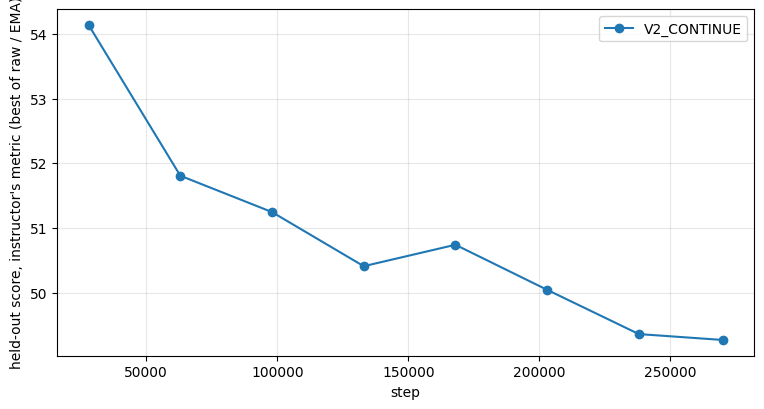

winner: V2_CONTINUE


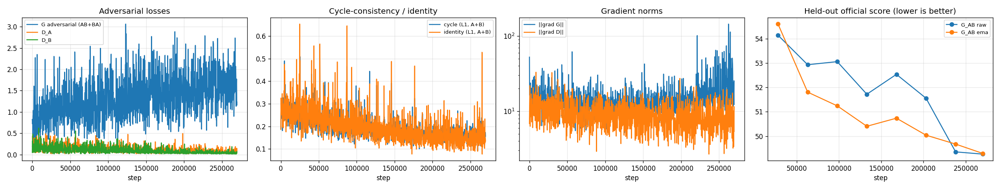

checkpoints/samples/step0000000_A_fakeB_recA.png


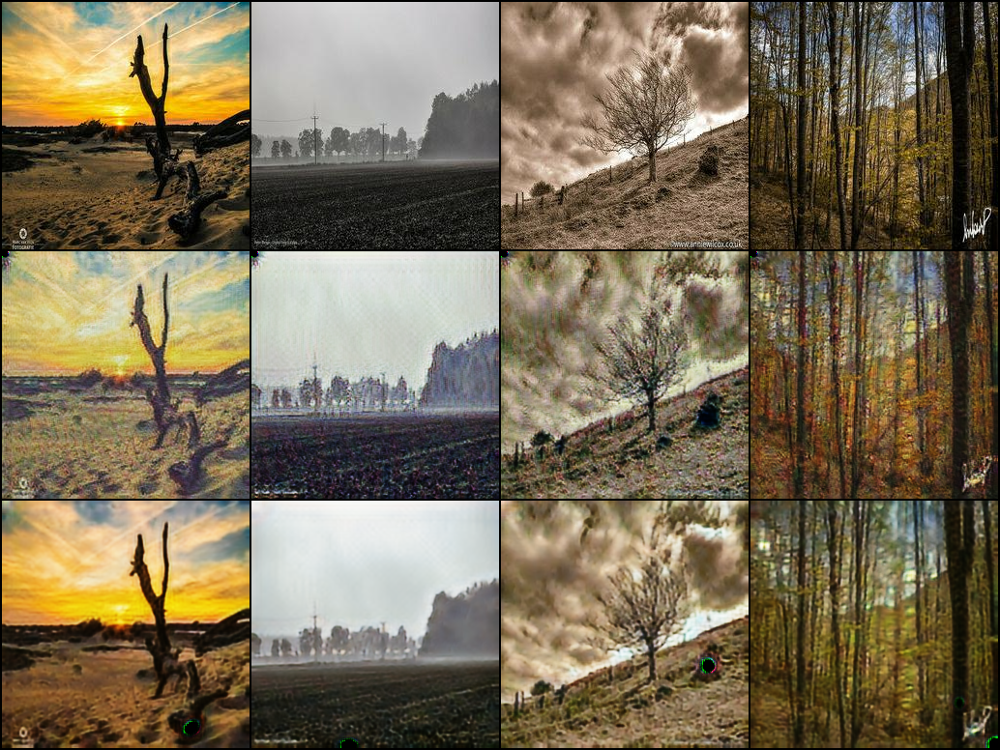

checkpoints/samples/step0026000_A_fakeB_recA.png


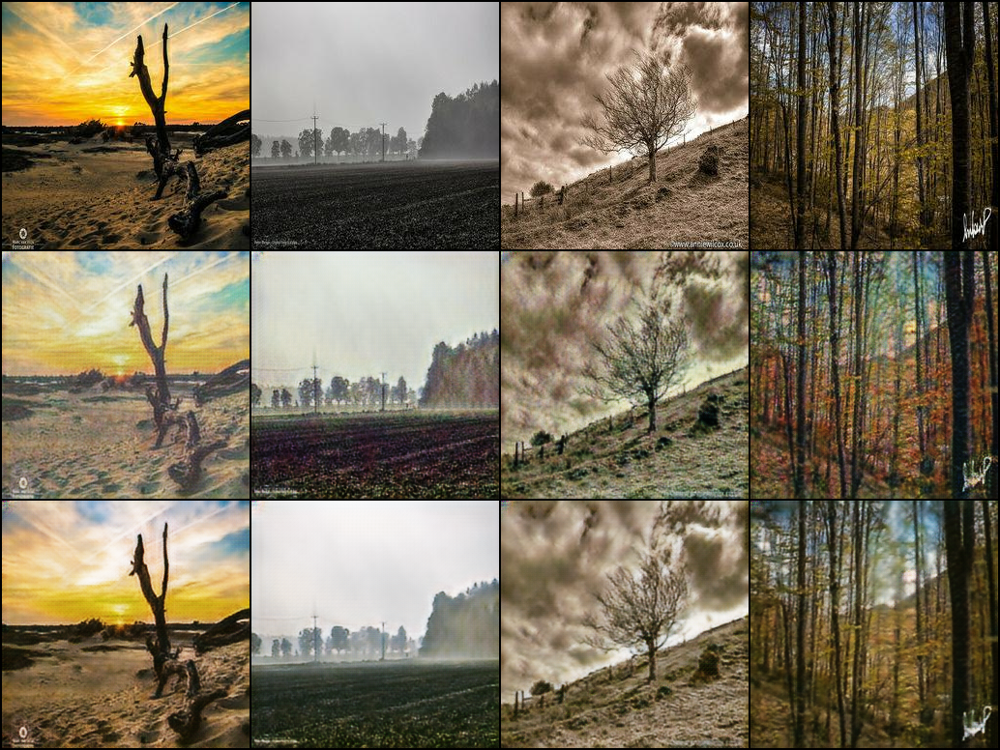

checkpoints/samples/step0140000_A_fakeB_recA.png


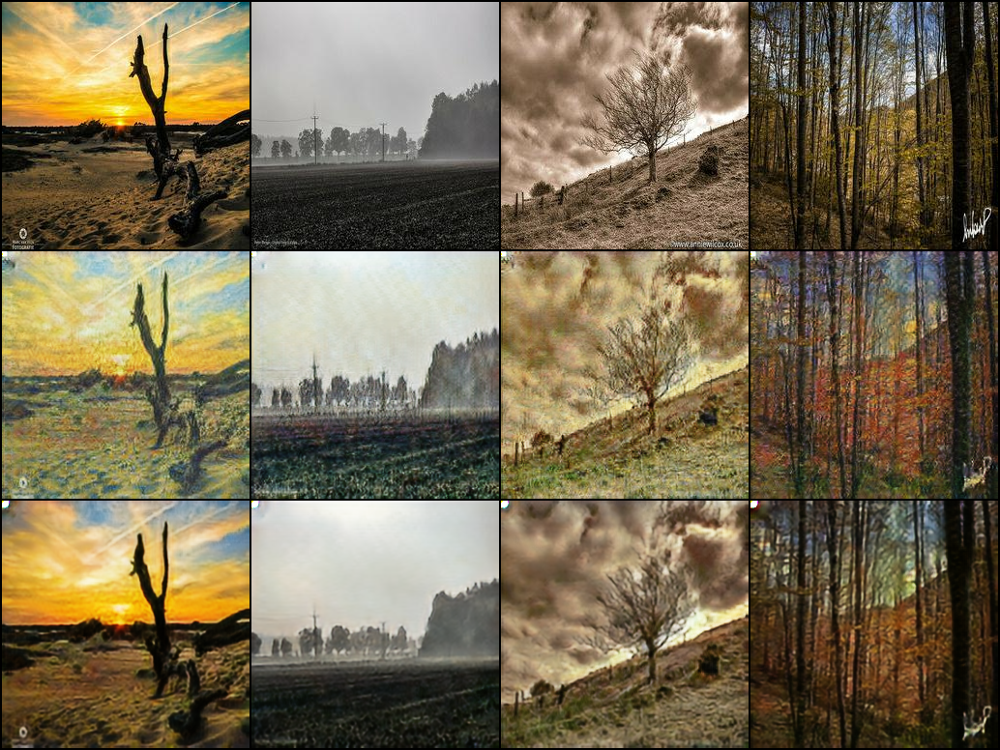

{
 "variant": "V2_CONTINUE",
 "checkpoints": {
  "G_AB": "checkpoints\\runs\\V2_CONTINUE\\G_AB.pt",
  "G_BA": "checkpoints\\runs\\V2_CONTINUE\\G_BA.pt",
  "D_A": "checkpoints\\runs\\V2_CONTINUE\\D_A.pt",
  "D_B": "checkpoints\\runs\\V2_CONTINUE\\D_B.pt"
 },
 "param_count": {
  "G_AB": 11378179,
  "G_BA": 11378179,
  "D_A": 2764737,
  "D_B": 2764737,
  "total": 28285832
 },
 "epochs": 270,
 "steps": 270000,
 "schedule": {
  "n": 270,
  "decay": 108,
  "from": 27,
  "every": 35,
  "calibrated": true
 },
 "budget_hours": 12.667,
 "training_time_sec": 24770.492136478424,
 "images_per_sec": 10.900066034714861,
 "peak_memory_mb": 19863.158203125,
 "nan_count": 0,
 "amp_overflow_skipped_steps": {
  "G": 0,
  "D": 0
 },
 "amp_dtype": "bf16",
 "grad_norm_G": {
  "mean": 15.285203087640692,
  "max": 520.6398315429688,
  "p95": 27.796553421020484
 },
 "grad_norm_D": {
  "mean": 9.333197270082985,
  "max": 69.85710144042969,
  "p95": 16.107929325103754
 },
 "final_loss_G": 3.5485487461090086,
 "fi

In [5]:
from IPython.display import Image, Markdown, display
import matplotlib.pyplot as plt
display(Markdown(open("checkpoints/variants_summary.md").read()))
fig, ax = plt.subplots(figsize=(9, 4.5))
for f in sorted(glob.glob("checkpoints/runs/*/metrics_train.json")):
    m = json.load(open(f))
    pts = [r for r in m["checkpoint_selection"]["fid_history"] if not r.get("calibration")]
    ax.plot([r["step"] for r in pts], [min(r["raw"], r["ema"] or 1e9) for r in pts], marker="o", label=m["variant"])
ax.set_xlabel("step"); ax.set_ylabel("held-out score, instructor's metric (best of raw / EMA)"); ax.grid(alpha=0.3); ax.legend()
plt.show()
print("winner:", open("checkpoints/PROMOTED_FROM.txt").read().splitlines()[0])
display(Image("checkpoints/loss_curves.png"))
samples = sorted(glob.glob("checkpoints/samples/*.png"))
for p in samples[:: max(1, len(samples) // 3)]:
    print(p); display(Image(p))
m = json.load(open("checkpoints/metrics_train.json"))
print(json.dumps({k: v for k, v in m.items() if k not in ("history",)}, indent=1)[:4000])

## 3. Evaluation in both directions: FID, KID, precision/recall, density/coverage, cycle-reconstruction L1, LPIPS, content cosine, identity L1

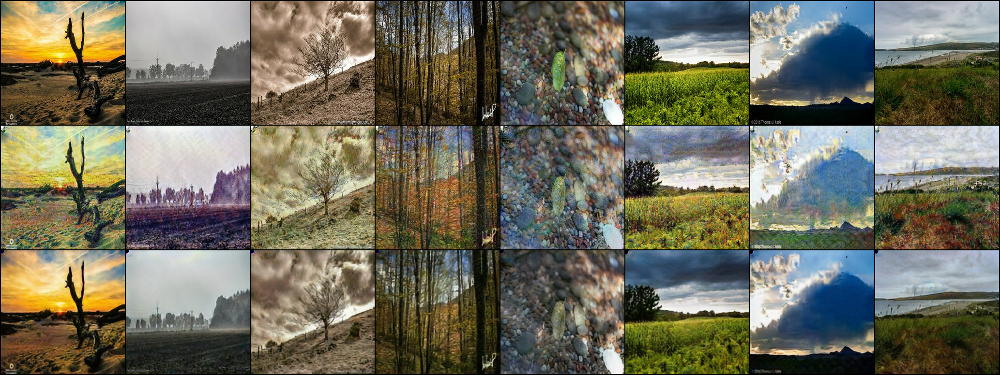

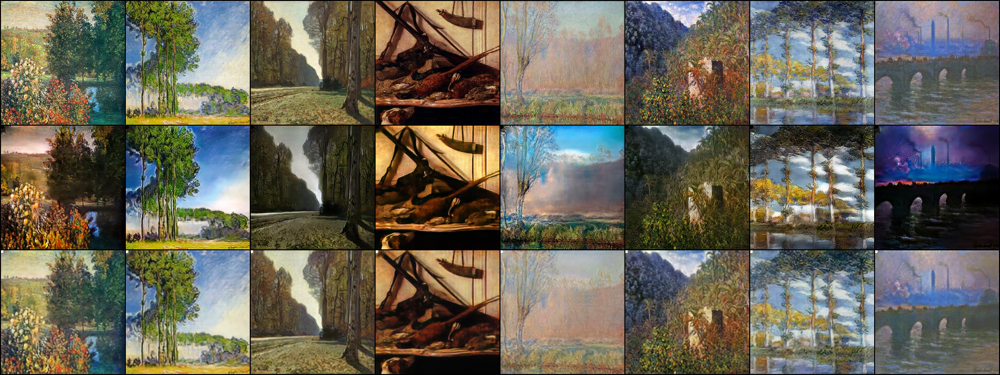

{
  "photo_to_monet": {
    "n_inputs": 1000,
    "n_reference_real": 300,
    "fid": 82.9969218574889,
    "kid_mean": 0.012618051910015344,
    "kid_std": 0.0008217013742116272,
    "precision": 0.576,
    "recall": 0.63,
    "density": 0.5556,
    "coverage": 0.9333333333333333,
    "k": 5,
    "cycle_reconstruction_l1": 0.10529142618179321,
    "lpips_input_vs_translation": 0.42035046219825745,
    "lpips_input_vs_reconstruction": 0.3470190763473511,
    "content_cosine_input_vs_translation": 0.7315567123275262,
    "identity_l1": 0.10027429461479187
  },
  "monet_to_photo": {
    "n_inputs": 300,
    "n_reference_real": 1000,
    "fid": 89.68361170203761,
    "kid_mean": 0.025717035297021847,
    "kid_std": 0.0009053521469669921,
    "precision": 0.6966666666666667,
    "recall": 0.428,
    "density": 0.5846666666666667,
    "coverage": 0.364,
    "k": 5,
    "cycle_reconstruction_l1": 0.08410986512899399,
    "lpips_input_vs_translation": 0.40190860629081726,
    "lpips_input_vs_

In [6]:
if not os.path.exists("checkpoints/metrics_eval.json"):
    !"{sys.executable}" src/evaluate.py --config config.yaml
display(Image("checkpoints/eval_photo2monet_input_fake_rec.png"), Image("checkpoints/eval_monet2photo_input_fake_rec.png"))
print(json.dumps(json.load(open("checkpoints/metrics_eval.json")), indent=2))

## 4. Kaggle submission (own generators only)
`submission.csv` is my v3 model's entry: `checkpoints/history/v3/G_AB.pt` applied to all 7,038 photos (images in `outputs/history/v3/pred_B2A`), scored with `evaluate_competition_stats.py`, which computes the Inception-v3 FID of the 7,038 translations against the competition's `real_stats.npz`. Its public score is −45.9695 and the team's public rank is 11; as agreed with the TA, this is the entry we report.

The final model is also scored with the instructor's evaluation script. `src/Part3_Evaluation_Script_run.ipynb` is the instructor's notebook run unchanged except for the folder paths, and `evaluate_local.py` is the same code as a script: the first 300 images of each folder (sorted by name), FID and MiFID for photo→Monet and Monet→photo, averaged. The leaderboard shows −(FID + MiFID)/2. Team: `PairProgramming_Team_06`.

In [7]:
# outputs/pred_A2B (all 300 Monet -> photo) comes from src/evaluate.py; outputs/pred_B2A = all 7,038 photos -> Monet
if len(glob.glob("outputs/pred_B2A/*.jpg")) < 7038:
    !"{sys.executable}" src/translate.py --config config.yaml --input ../data/photo_jpg --output outputs/pred_B2A --flat
print(len(glob.glob("outputs/pred_A2B/*.jpg")), "Monet -> photo |", len(glob.glob("outputs/pred_B2A/*.jpg")), "photo -> Monet")
# final model: the instructor's script as a script (same functions and defaults)
!"{sys.executable}" evaluate_local.py --pred_dir outputs --no_csv
# submission.csv: the v3 Kaggle entry, re-scored from v3's 7,038 translations
!"{sys.executable}" evaluate_competition_stats.py --gen outputs/history/v3/pred_B2A --no_csv
d = json.load(open("submission_details.json"))
print(open("submission.csv").read())
print(f"submission.csv: {d['model']} | Kaggle public score {d['kaggle_public_score']}")

300 Monet -> photo | 7038 photo -> Monet


device mps | counts {'real_monet': 300, 'gen_b2a': 300, 'real_photo': 300, 'gen_a2b': 300}
[Photo->Monet] FID=96.956  MiFID=0.4024
[Monet->Photo] FID=106.862  MiFID=0.4139
submission: FID=101.909 MiFID=0.4082 -> leaderboard -51.1585


7038 generated images | device mps


{
  "n_generated": 7038,
  "FID": 91.53676721892396,
  "MiFID": 0.4024646474810304,
  "MiFID_all_pairs": 0.4054435454944843,
  "score_mean": 45.96961593320249
}


ID,FID,MiFID
1,91.537,0.402

submission.csv: v3, best epoch 11 (checkpoints/history/v3/G_AB.pt) | Kaggle public score -45.9695 (submission ref 56747128); team public rank 11


## 5. Blinded human audit (30 fixed samples, 2 raters)

In [8]:
if not os.path.exists("checkpoints/audit/ratings_rater1.csv"):
    !"{sys.executable}" src/human_audit.py prepare --config config.yaml
sheets = [f"checkpoints/audit/ratings_{r}.csv" for r in ("rater1", "rater2")]
filled = all(os.path.exists(f) and open(f).read().count(",,,") == 0 for f in sheets)
if filled:
    !"{sys.executable}" src/human_audit.py score --config config.yaml
else:
    print("waiting for both raters to fill checkpoints/audit/ratings_rater{1,2}.csv")

{
  "n_samples": 30,
  "style": {
    "mean_rater1": 3.566666666666667,
    "mean_rater2": 3.7333333333333334,
    "mean_both": 3.65,
    "cohens_kappa": 0.0066225165562913135,
    "cohens_kappa_quadratic": 0.12645590682196328,
    "exact_agreement_pct": 33.33333333333333,
    "within_1_agreement_pct": 83.33333333333334
  },
  "content": {
    "mean_rater1": 3.8333333333333335,
    "mean_rater2": 4.033333333333333,
    "mean_both": 3.933333333333333,
    "cohens_kappa": 0.07407407407407396,
    "cohens_kappa_quadratic": 0.289940828402367,
    "exact_agreement_pct": 33.33333333333333,
    "within_1_agreement_pct": 83.33333333333334
  },
  "artifacts": {
    "mean_rater1": 3.433333333333333,
    "mean_rater2": 4.066666666666666,
    "mean_both": 3.75,
    "cohens_kappa": -0.03937007874015763,
    "cohens_kappa_quadratic": 0.2782834850455136,
    "exact_agreement_pct": 26.666666666666668,
    "within_1_agreement_pct": 83.33333333333334
  },
  "overall_human_audit_score_1to5": 3.7777777777

## 6. Metric tables and deliverables

In [9]:
!cd ../.. && "{sys.executable}" tools/export_reports.py --member {MEMBER} --task task3
!cd ../.. && "{sys.executable}" tools/make_tables.py --member {MEMBER}
if IN_COLAB:
    colab.sync_back(DRIVE_REPO, TASK, MEMBER)

wrote task3_gan/sivasurya_chandran/metrics_report.csv
wrote task3_gan/sivasurya_chandran/full_metrics_report.csv


kept existing task3_gan/sivasurya_chandran/failure_analysis.md


# Metric tables — sivasurya_chandran (from `checkpoints/`)


## Task 1

| Metric | Value |
|---|---|
| Training cross-entropy (nats/char) | 0.6303 |
| Validation cross-entropy (nats/char) | 0.6385 |
| Perplexity (val) | 1.8937 |
| Bits-per-character (val) | 0.9212 |
| Generalization gap (val − train) | 0.0082 |
| Top-1 next-char accuracy (val) | 0.7955 |
| Distinct-1 / 2 / 3 | 0.2525 / 0.6764 / 0.8860 |
| Repeated 4-gram rate (sampled / greedy) | 0.0063 / 0.2671 |
| Grad norm mean / p95 / max | 0.343 / 0.489 / 7.770 |
| NaN steps / loss spikes | 0 / 0 |
| fp16 overflow steps skipped by GradScaler | 41 |
| Parameter count | 4,827,648 |
| Training tokens/sec | 133,346 |
| Generation tokens/sec | 217.1832 |
| Peak memory (MB) | 943.9868 |
| Total training time (s) | 6,735.6416 |

## Task 2

| Metric | baseline (bag) | experimental_1 (cnn) | experimental_2 (bilstm) |
|---|---|---|---|
| Accuracy | 0.9332 | 0.9502 | 0.9581 |
| Precision macro | 0.9332 | 0.9502 | 0.9581 |
| Recall macro | 0.

## How the final design came about

Before the final run I trained three shorter versions of this model (configs, logs and samples in `configs/history/`, `logs/history/`, `checkpoints/history/`; see `HISTORY.md`). Each one changed the design: the first had checkerboard artifacts from transposed convolutions, so the generators use resize-convolution; the second showed that FID improved almost only while the learning rate decayed, so the final run uses a long schedule with a long decay; the third showed the outputs needed more Monet-like texture rather than better colour.